In [1]:
!pip install statsmodels

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

sns.set_style("darkgrid")

In [6]:
dates = pd.date_range(start='2022-01-01', end='2023-12-31', freq='D')

trend = np.linspace(1000, 2000, len(dates))

seasonality = 200 * np.sin(2 * np.pi * dates.dayofyear / 7)

noise = np.random.normal(0, 100, len(dates))

sales = trend + seasonality + noise

df = pd.DataFrame({'Date': dates, 'Sales': sales})
df.set_index('Date', inplace=True)

df.head()

,Sales
Date,
2022-01-01,1212.890922
2022-01-02,1096.792737
2022-01-03,1070.035157
2022-01-04,1101.358864
2022-01-05,837.125493


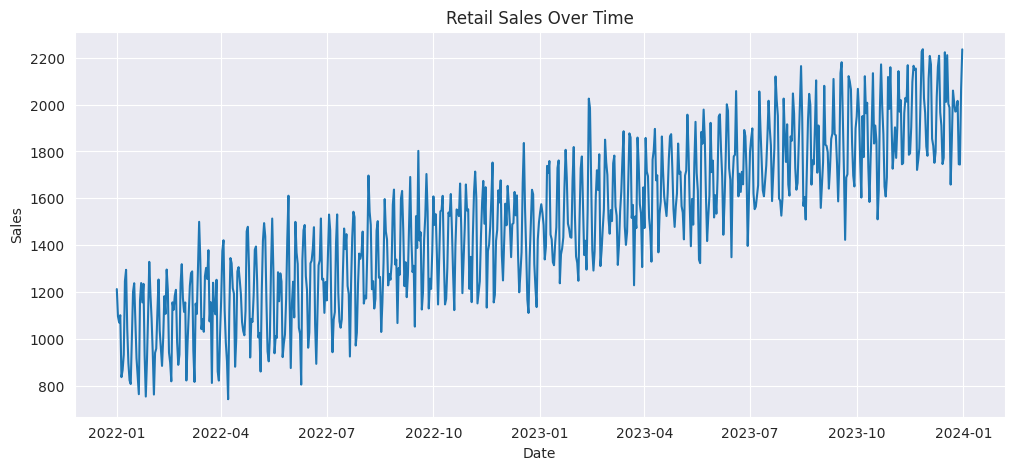

In [7]:
plt.figure(figsize=(12,5))
plt.plot(df['Sales'])
plt.title("Retail Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

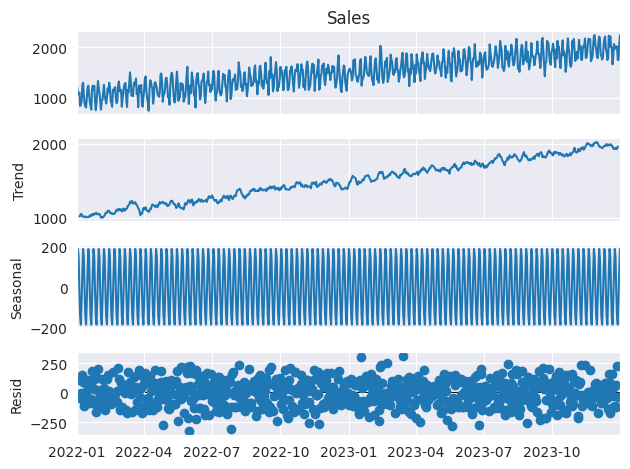

In [8]:
decomposition = seasonal_decompose(df['Sales'], model='additive', period=7)

decomposition.plot()
plt.show()

In [9]:
result = adfuller(df['Sales'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -0.5661929585958126
p-value: 0.8784395322600671


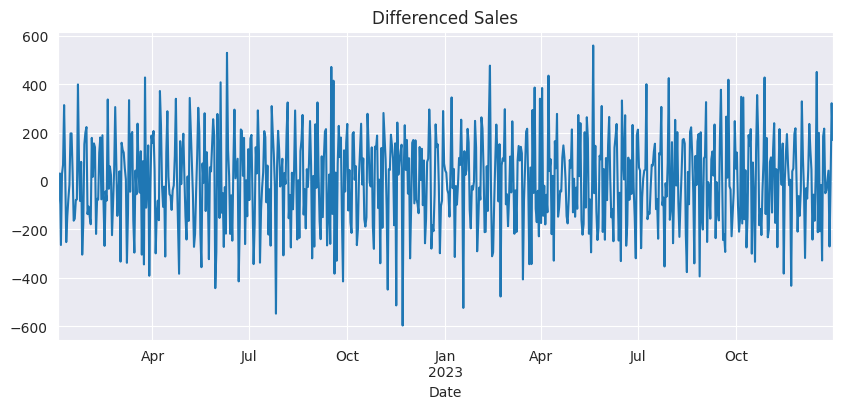

In [10]:
df['Sales_diff'] = df['Sales'].diff()

df['Sales_diff'].dropna().plot(figsize=(10,4))
plt.title("Differenced Sales")
plt.show()

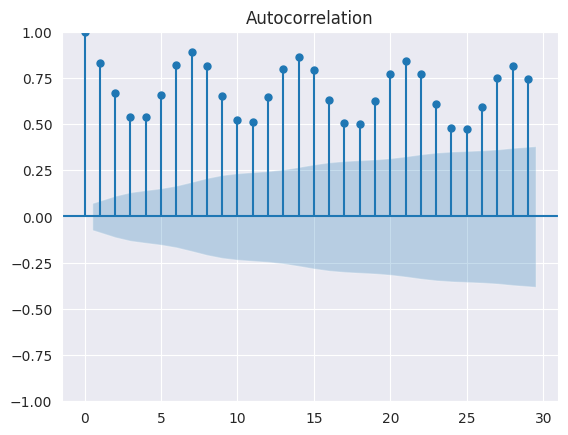

In [11]:
plot_acf(df['Sales'].dropna())
plt.show()

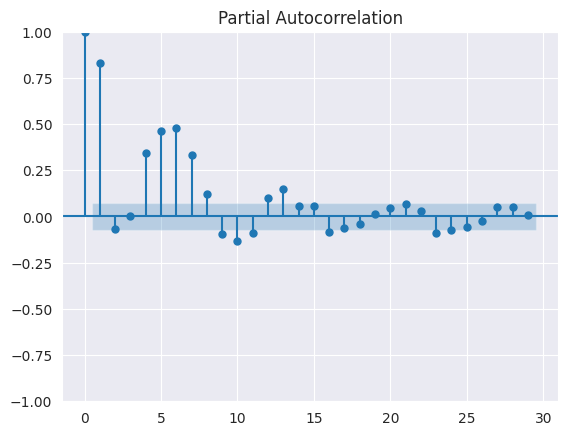

In [12]:
plot_pacf(df['Sales'].dropna())
plt.show()